In [4]:
pip install rebound

python(47433) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install reboundx

python(47434) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [6]:
import rebound
import reboundx
import numpy as np
import matplotlib.pyplot as plt
from pycbc.waveform import get_td_waveform

python(47435) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/opt/anaconda3/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
python(47437) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [7]:
pip install gwpy

python(47438) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [8]:
import math
import scipy.constants as const

In [9]:
from gwpy.table import EventTable

In [11]:
sim = rebound.Simulation()
sim.units = ("m", "s", "Msun")

In [100]:
#Math tests
pi = const.pi
G = sim.G
c = const.c
#meter_to_au = 149597870700.0
#c = c / meter_to_au * 60 * 60 * 24 * 365.25
print(G)
print(pi)
print(c)

1.3271244004193937e+20
3.141592653589793
299792458.0


In [14]:
# Separation distance
def seperation_distance_r(m_1, m_2, e_i):
    numerator = G * (m_1 + m_2)
    denominator = ((pi * ((1 - e_i**2)**1.5))/((1 + e_i)**1.1954))**2
    r = (numerator/denominator)**(1/3)
    return r

In [15]:
#Randomize eccentricity
e = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]

In [16]:
#Testing
def testing(m_1, m_2, e_i):
    expected_value = 28287008.540600967
    calculated_value = seperation_distance_r(m_1, m_2, e_i)
    print(calculated_value)
    if abs(expected_value - calculated_value) < 0.00000001:
        print("working")
    else:
        print("not working")

In [17]:
testing(10, 19, 0.77)

28287008.540600967
working


In [19]:
def radiation_reaction_force(sim_pointer):
    sim = sim_pointer.contents
    if sim.N < 2: return

    ps = sim.particles
    p1 = ps[0]
    p2 = ps[1]

    # Relative position and velocity
    dx, dy, dz = p1.x - p2.x, p1.y - p2.y, p1.z - p2.z
    dvx, dvy, dvz = p1.vx - p2.vx, p1.vy - p2.vy, p1.vz - p2.vz

    r_sq = dx**2 + dy**2 + dz**2
    r = np.sqrt(r_sq)
    v_sq = dvx**2 + dvy**2 + dvz**2

    # Radial velocity (r_dot)
    rv_dot = dx*dvx + dy*dvy + dz*dvz
    r_dot = rv_dot / r

    # Mass parameters
    m1, m2 = p1.m, p2.m
    M = m1 + m2
    mu = m1 * m2 / M
    eta = mu / M
    
    # Constants (Ensure G and c are accessible here)
    # 2.5PN Acceleration Factor
    A_const = (8.0/5.0) * (G * M * eta) / (r**3) * (G * M / (c**5))

    # Coefficients
    term_A = (17.0/3.0) * (G * M / r) + 3.0 * v_sq
    term_B = v_sq + 3.0 * (G * M / r)

    # Relative Acceleration Vector
    # CORRECTED FORMULA:
    # a = - A_const * ( term_B * v - term_A * r_dot * n )
    
    ax_rel = -A_const * (term_B * dvx - term_A * r_dot * (dx/r))
    ay_rel = -A_const * (term_B * dvy - term_A * r_dot * (dy/r))
    az_rel = -A_const * (term_B * dvz - term_A * r_dot * (dz/r))

    # Apply forces
    p1.ax += ax_rel * (m2 / M)
    p1.ay += ay_rel * (m2 / M)
    p1.az += az_rel * (m2 / M)

    p2.ax -= ax_rel * (m1 / M)
    p2.ay -= ay_rel * (m1 / M)
    p2.az -= az_rel * (m1 / M)

In [30]:
def run_simulation(m_1, m_2, e):
    for e_i in e:
        sim = rebound.Simulation()
        r = seperation_distance_r(m_1, m_2, e_i)
        print(e_i)
        print(r)
        sim.add(m=m_1)
        sim.add(m=m_2, a=r, e=e_i)
        sim.move_to_com()
        sim.integrator = "ias15"
        rebx = reboundx.Extras(sim)
        
        #1PN order
        gr = rebx.load_force("gr")
        rebx.add_force(gr)
        gr.params["c"] = c
        
        #2.5PN order
        sim.additional_forces = radiation_reaction_force
        sim.force_is_velocity_dependent = 1
        
        ps = sim.particles
        ps[0].r = 2 * G * ps[0].m / (c**2)
        ps[1].r = 2 * G * ps[1].m / (c**2)
        
        # 2. Enable Merger
        sim.collision = "direct"
        sim.collision_resolve = "merge"
        
        t_max = 2000000
        dt_check = 1000
        
        step = 0
        
        while sim.t < t_max:
            sim.integrate(sim.t + dt_check)
            step += 1
            if step % int(100000/dt_check) == 0:
                print(f"t = {sim.t:.2f}")
        
            if sim.N < 2:
                print(f"MERGER DETECTED at time t = {sim.t:.5f}")
                break
        
        sim.status()
        rebound.OrbitPlot(sim)

[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
0.1
12417100.817246934
t = 100000.00
t = 200000.00
t = 300000.00
t = 400000.00
t = 500000.00
t = 600000.00
t = 700000.00


/opt/anaconda3/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: At least 10 predictor corrector loops in IAS15 did not converge. This is typically an indication of the timestep being too large.
  warnings.warn(msg[1:], RuntimeWarning)
/opt/anaconda3/lib/python3.12/site-packages/gwpy/plot/axes.py:82: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  return func(self, **kw)
/opt/anaconda3/lib/python3.12/site-packages/rebound/plotting.py:314: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.ax.set_ylim([limits_y[0]-0.05*height,limits_y[1]+0.05*height])


MERGER DETECTED at time t = 757000.00000
---------------------------------
REBOUND version:     	4.4.10
REBOUND built on:    	Jul  1 2025 16:07:48
Number of particles: 	1
Selected integrator: 	ias15
Simulation time:     	7.5700000000000000e+05
Current timestep:    	395.629018
---------------------------------
<rebound.particle.Particle object at 0x302661150, m=110.0 x=-3.5644325144278327e-07 y=1.6939253225781325e-12 z=0.0 vx=-4.4247497633913656e-10 vy=2.232963088182956e-15 vz=0.0>
---------------------------------
The following fields have non-default values:
t:
< 0.000000e+00
---
> 7.570000e+05
dt:
< 1.000000e-03
---
> 3.956290e+02
N:
< 0
---
> 1
force_is_velocity_dependent:
< 0
---
> 1
collision:
< 0
---
> 1
ri_ias15.iterations_max_exceeded:
< 0
---
> 11
walltime:
< 0.000000e+00
---
> 4.359490e-01
walltime_last_steps:
< 0.000000e+00
---
> 2.593446e-04
steps_done:
< 0
---
> 1658
dt_last_done:
< 0.000000e+00
---
> 2.771904e+02
rand_seed:
< 271409
---
> 1375788531
functionpointers:
< (4

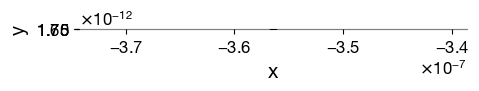

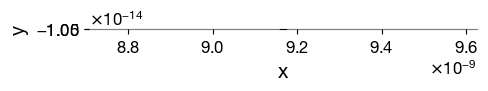

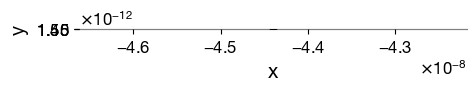

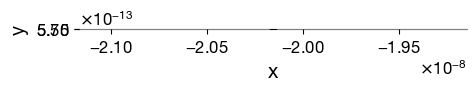

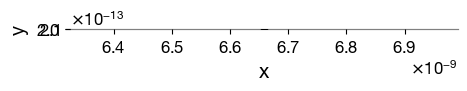

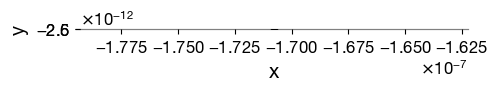

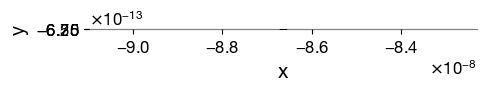

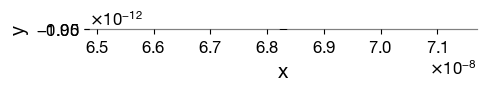

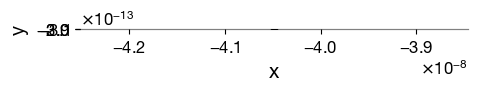

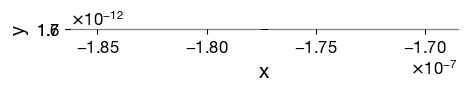

In [32]:
m_1 = 10
m_2 = 100
e = e
print(e)
run_simulation(m_1, m_2, e)

In [33]:
def get_theoretical_peak_freq(sim):
    # Calculate the peak GW frequency based on the current orbit shape (a, e)
    
    if sim.N < 2: return 0

    orbits = sim.orbits()
    o = orbits[0]
    e = o.e
    
    f_orb = o.n / (2 * np.pi)
    
    # Wen's Formula for Peak GW Frequency
    numerator = 2 * (1 + e)**1.1954
    denominator = (1 - e**2)**1.5
    f_peak = f_orb * (numerator / denominator)
    
    return f_peak

In [86]:
def get_strain(sim, dist_to_source):
    ps = sim.particles
    
    x, y = ps[0].x - ps[1].x, ps[0].y - ps[1].y
    vx, vy = ps[0].vx - ps[1].vx, ps[0].vy - ps[1].vy
    
    m1, m2 = ps[0].m, ps[1].m
    M_tot = m1 + m2
    mu = (m1 * m2) / M_tot
    
    # Calculate radius squared and cubed
    r_sq = x**2 + y**2
    r_cubed = r_sq**1.5
    
    prefactor = G / (c**4 * dist_to_source)
    
    # Corrected formula including both velocity and position terms
    h_plus = prefactor * 2 * mu * ((vx**2 - vy**2) - (G * M_tot / r_cubed) * (x**2 - y**2))
    h_cross = prefactor * 4 * mu * ((vx * vy) - (G * M_tot / r_cubed) * (x * y))
    
    return h_plus, h_cross

In [96]:
def run_simulation_final(m_1, m_2, e_i, dist_source_meters):
    sim = rebound.Simulation()
    sim.units = ("m", "s", "Msun")
    
    # Calculate Initial Separation (Wen's Formula for 1 Hz)
    r = seperation_distance_r(m_1, m_2, e_i)
    
    print(f"--- Simulation Setup (e={e_i}) ---")
    print(f"Initial Separation: {r:.2e} m")

    #Particles
    sim.add(m=m_1)
    sim.add(m=m_2, a=r, e=e_i)
    sim.move_to_com() 

    #Forces
    sim.integrator = "ias15"
    rebx = reboundx.Extras(sim)
    gr = rebx.load_force("gr")
    rebx.add_force(gr)
    gr.params["c"] = c
    sim.additional_forces = radiation_reaction_force 
    sim.force_is_velocity_dependent = 1
    
    ps = sim.particles
    ps[0].r = 2 * G * ps[0].m / (c**2)
    ps[1].r = 2 * G * ps[1].m / (c**2)
    sim.collision = "direct"
    sim.collision_resolve = "merge"

    # --- SIMULATION LOOP ---
    dt_coarse = 1.0
    dt_fine = 1.0 / 4096.0
    
    waveform_data = []
    recording = False
    step_count = 0
    
    print("Starting integration...")

    while sim.N == 2:
        peak_freq = get_theoretical_peak_freq(sim)
        
        #INSPIRAL until 10Hz
        if not recording:
            if peak_freq >= 10.0:
                print(f"TRIGGER: 10 Hz reached at t={sim.t:.2f}s (Freq={peak_freq:.2f} Hz)")
                recording = True
                # Switch to fine steps
            else:
                sim.integrate(sim.t + dt_coarse)
                step_count += 1
                if step_count % 1000 == 0:
                    print(f"t={sim.t:.1e} s | Peak Freq={peak_freq:.3f} Hz")
                continue

        if recording:
            sim.integrate(sim.t + dt_fine)
            
            # Save data
            h_p, h_c = get_strain(sim, dist_source_meters)
            waveform_data.append([sim.t, h_p, h_c])
            
            # Stop if passed 30Hz
            if peak_freq > 30.0:
                print("Target frequency (30 Hz) reached. Stopping.")
                break
                
    return np.array(waveform_data)

In [102]:
wave = run_simulation_final(10, 100, 0.01, 10**10)

--- Simulation Setup (e=0.01) ---
Initial Separation: 1.15e+07 m
Starting integration...
t=1.0e+03 s | Peak Freq=1.149 Hz
t=2.0e+03 s | Peak Freq=1.439 Hz
t=3.0e+03 s | Peak Freq=2.801 Hz
TRIGGER: 10 Hz reached at t=3194.00s (Freq=10.34 Hz)
Target frequency (30 Hz) reached. Stopping.


In [41]:
def plot_gw_wavestrain(data, e):

    t_vals = data[:, 0]
    h_plus = data[:, 1]
    h_cross = data[:, 2]
    
    t_plot = t_vals - t_vals[0]
    
    plt.figure(figsize=(12, 6))
    
    plt.plot(t_plot, h_plus, label='Strain $h_+$', color='tab:blue', linewidth=1)
    
    plt.title(f"Gravitational Wave Strain (10 Hz to Merger) | e={e}", fontsize=14)
    plt.xlabel("Time since 10 Hz Trigger (seconds)", fontsize=12)
    plt.ylabel("Strain Amplitude (dimensionless)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

--- Simulation Setup (e=0.5) ---
Initial Separation: 1.48e+07 m
Starting integration...
t=1.0e+03 s | Peak Freq=1.008 Hz
t=2.0e+03 s | Peak Freq=1.016 Hz
t=3.0e+03 s | Peak Freq=1.025 Hz
t=4.0e+03 s | Peak Freq=1.035 Hz
t=5.0e+03 s | Peak Freq=1.045 Hz
t=6.0e+03 s | Peak Freq=1.056 Hz
t=7.0e+03 s | Peak Freq=1.067 Hz
t=8.0e+03 s | Peak Freq=1.080 Hz
t=9.0e+03 s | Peak Freq=1.093 Hz
t=1.0e+04 s | Peak Freq=1.108 Hz
t=1.1e+04 s | Peak Freq=1.124 Hz
t=1.2e+04 s | Peak Freq=1.141 Hz
t=1.3e+04 s | Peak Freq=1.160 Hz
t=1.4e+04 s | Peak Freq=1.181 Hz
t=1.5e+04 s | Peak Freq=1.204 Hz
t=1.6e+04 s | Peak Freq=1.230 Hz
t=1.7e+04 s | Peak Freq=1.261 Hz
t=1.8e+04 s | Peak Freq=1.295 Hz
t=1.9e+04 s | Peak Freq=1.336 Hz
t=2.0e+04 s | Peak Freq=1.385 Hz
t=2.1e+04 s | Peak Freq=1.445 Hz
t=2.2e+04 s | Peak Freq=1.523 Hz
t=2.3e+04 s | Peak Freq=1.627 Hz
t=2.4e+04 s | Peak Freq=1.782 Hz
t=2.5e+04 s | Peak Freq=2.047 Hz
t=2.6e+04 s | Peak Freq=2.731 Hz
TRIGGER: 10 Hz reached at t=26639.00s (Freq=10.11 Hz)


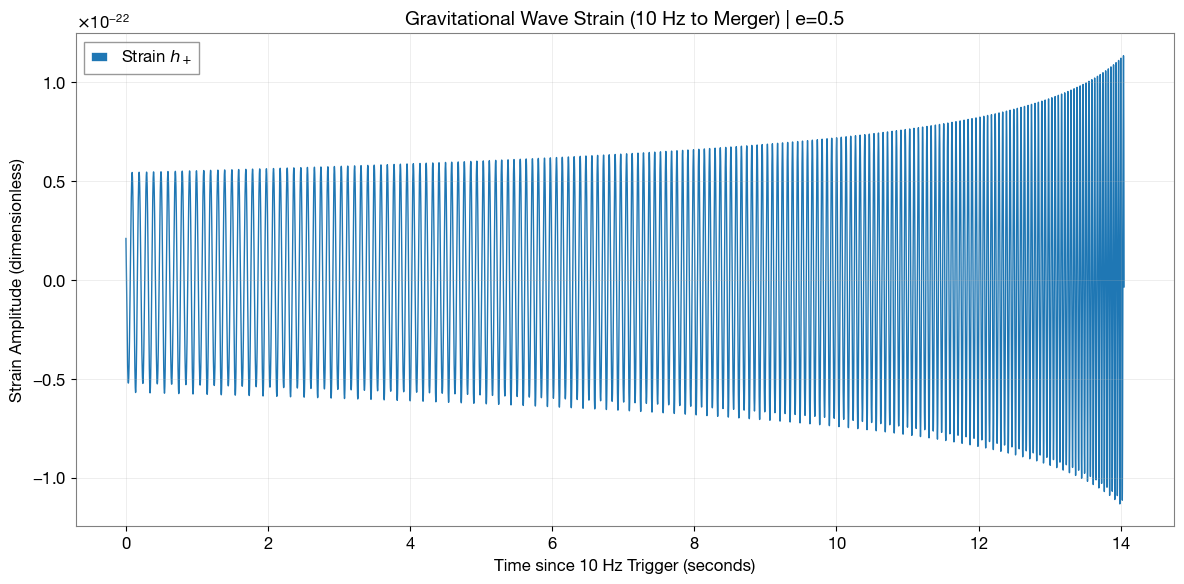

In [42]:
m_1 = 24.8
m_2 = 13.6
e = [0.5]
mpc_to_meter = 3.08567758128e22
distance = 1000 * mpc_to_meter
for e_i in e:
    data = run_simulation_final(m_1, m_2, e_i, distance)
    plot_gw_wavestrain(data, e_i)

In [104]:
def calculate_simple_match(strain1, strain2):
    # 1. Normalize both waveforms (make them "unit vectors")
    # This removes amplitude differences, so we only compare the SHAPE/PHASE.
    norm1 = np.sqrt(np.sum(strain1**2))
    norm2 = np.sqrt(np.sum(strain2**2))
    
    s1_norm = strain1 / norm1
    s2_norm = strain2 / norm2
    
    # 2. Calculate the dot product (The Match)
    # 1.0 = Identical
    # 0.0 = Completely different
    match = np.abs(np.dot(s1_norm, s2_norm))
    
    return match

/opt/anaconda3/lib/python3.12/site-packages/gwpy/plot/plot.py:296: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  super().show(warn=warn)


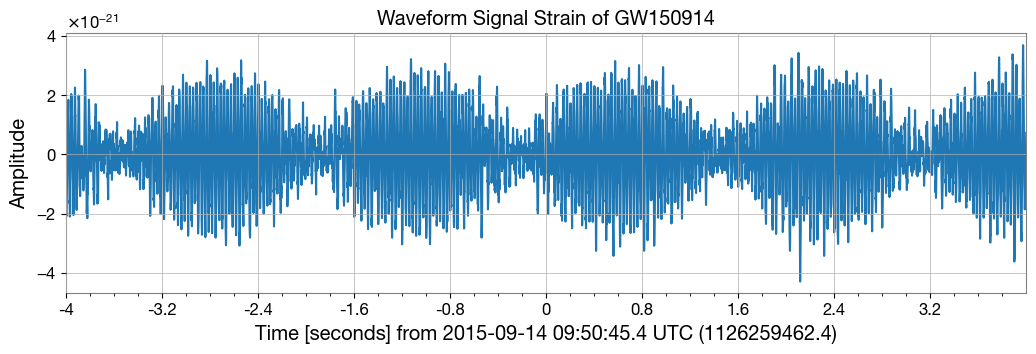

In [106]:
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps

event = "GW150914"
ifo = "L1"
gps = event_gps(event)

# 1) Fetch a LONGER segment for stable PSD + to avoid edge artifacts
pad = 16  # seconds (8–32 is typical)
strain = TimeSeries.fetch_open_data(ifo, gps - pad, gps + pad, cache=True)

# 2) Taper (reduces boundary discontinuities)
strain = strain.taper()

# --- REPLACEMENT FOR STEPS #3 and #4 ---

# 1. WHITEN FIRST (using the longer segment to estimate PSD)
# Whitening flattens the noise spectrum.
#strain_w = strain.whiten(fftlength=1, overlap=0.5)

# 2. BANDPASS SECOND
# Now we remove the high frequency noise and low frequency seismic drift.
# (30-400Hz is a tighter, cleaner range for GW150914)
strain_wb = strain.bandpass(20, 300) #100, 300
strain_wb = strain_wb.crop(gps - 4, gps + 4)

if strain_wb.sample_rate.value != 4096:
    strain_wb = strain_wb.resample(4096)

# --- VISUALIZATION 1: TIME DOMAIN PLOT ---
fig1 = strain_wb.plot()
ax1 = fig1.gca()
ax1.set_title("Waveform Signal Strain of " + f"{event}")
ax1.set_ylabel("Amplitude")
ax1.set_epoch(gps)  # Sets the X-axis to be relative to the event time (0 = merger)
fig1.show()

In [116]:
e_i = 0
data_sim = run_simulation_final(34.6, 30.0, e_i, distance)
h_sim = data_sim[:, 1] # Get h_plus
min_len = min(len(h_sim), len(strain_wb))
match_score = calculate_simple_match(h_sim[:min_len], strain_wb[:min_len])
print(f"\n--- RESULTS ---")
print(f"Match Score: {match_score:.6f}")

--- Simulation Setup (e=0) ---
Initial Separation: 9.54e+06 m
Starting integration...
t=1.0e+03 s | Peak Freq=1.211 Hz
t=2.0e+03 s | Peak Freq=1.826 Hz
TRIGGER: 10 Hz reached at t=2496.00s (Freq=10.24 Hz)
Target frequency (30 Hz) reached. Stopping.

--- RESULTS ---
Match Score: 0.003722


In [118]:
from scipy.signal import correlate, butter, filtfilt

In [120]:
def bandpass_filter(data, lowcut, highcut, fs=4096):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, data)

In [122]:
def calculate_max_overlap(sim_strain, ligo_strain):
    sim_strain = np.nan_to_num(sim_strain)
    ligo_strain = np.nan_to_num(ligo_strain)
    
    sim_norm = sim_strain / (np.linalg.norm(sim_strain) + 1e-16)
    ligo_norm = ligo_strain / (np.linalg.norm(ligo_strain) + 1e-16)
    
    cross_corr = correlate(ligo_norm, sim_norm, mode='full')

    best_match_score = np.max(np.abs(cross_corr))
    
    return best_match_score

In [124]:
calculate_max_overlap(h_sim, strain_wb)

9.971369152783749e-05

Fetching LIGO Data for GW150914...
--- Simulation Setup (e=0.0) ---
Initial Separation: 9.54e+06 m
Starting integration...
t=1.0e+03 s | Peak Freq=1.211 Hz
t=2.0e+03 s | Peak Freq=1.826 Hz
TRIGGER: 10 Hz reached at t=2496.00s (Freq=10.24 Hz)
Target frequency (30 Hz) reached. Stopping.
Correlating...
Max Match Score: 3.2086


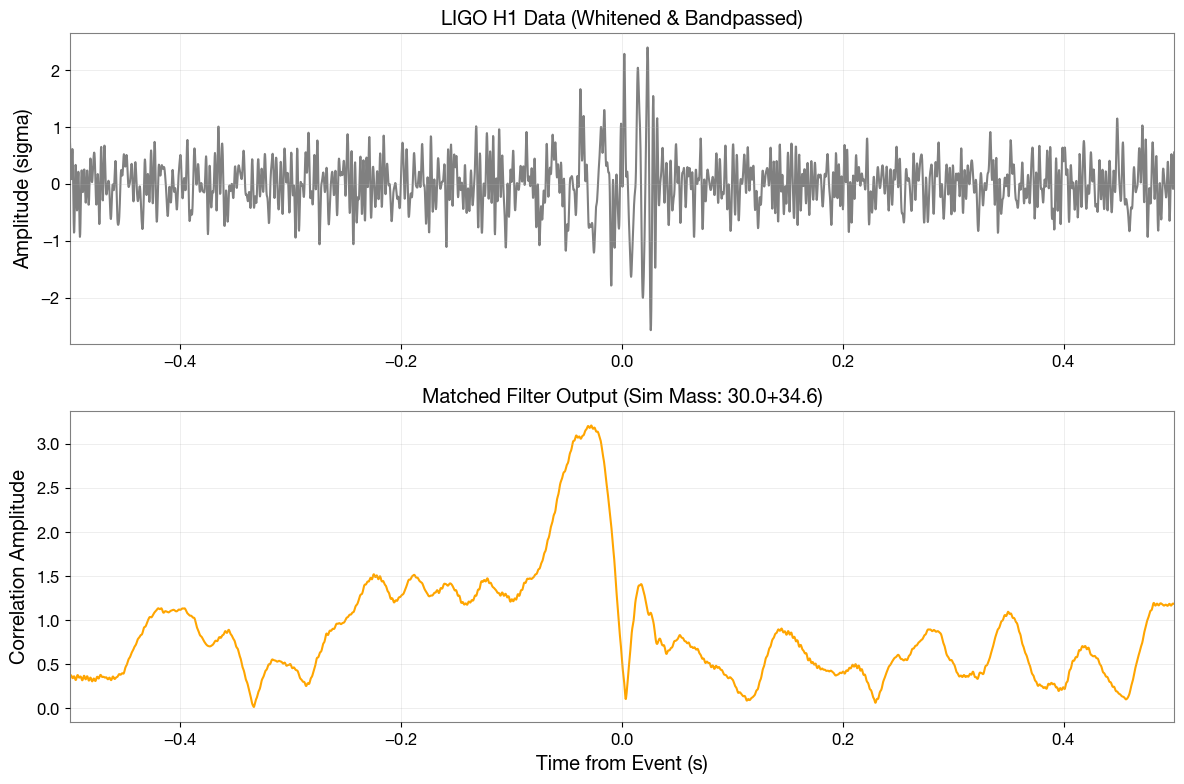

In [126]:
import numpy as np
import matplotlib.pyplot as plt
import rebound
import reboundx
from scipy.signal import correlate, hilbert, butter, filtfilt
from gwpy.timeseries import TimeSeries
from scipy.signal.windows import tukey # Import the windowing function


# --- 1. CONFIGURATION FOR GW150914 ---
# The masses must match the event to get the correct frequency evolution (chirp)
M1 = 30.0  # Solar masses
M2 = 34.6  # Solar masses
DISTANCE_MPC = 470 # Approx distance for amplitude scaling
# LIGO event time
GPS_TIME = 1126259462.4

MPC_TO_M = 3.086e22

# --- 3. GET AND PROCESS LIGO DATA ---
print("Fetching LIGO Data for GW150914...")
# Fetch 32 seconds of data around the event
data = TimeSeries.fetch_open_data('H1', GPS_TIME - 16, GPS_TIME + 16)

# A. WHITENING (Crucial Step!)
# Whitening normalizes the noise power across frequencies
white_data = data.whiten(4, 2) # 4s segment, 2s overlap

# B. BANDPASS FILTERING
# Focus on the 30Hz - 400Hz band where the signal exists
bp_data = white_data.bandpass(30, 400)

# --- 4. PREPARE SIMULATION TEMPLATE ---
# Run sim with e=0.001 (Control Group)


#h_p, h_c, t_sim = get_simulated_waveform(M1, M2, 0.001)
dist_source_meters = DISTANCE_MPC * MPC_TO_M
h_p = run_simulation_final(M1, M2, 0.0, dist_source_meters)
h_plus_1d = h_p[:, 1]

# Apply same bandpass to template
# Create a TimeSeries object for easier filtering
template_ts = TimeSeries(h_plus_1d, sample_rate=4096) # Assuming sim step matches 4096Hz
template_ts = template_ts.whiten(4, 2)
template_bp = template_ts.bandpass(30, 400)

# --- 5. PERFORM MATCHED FILTERING ---
print("Correlating...")

ligo_strain = bp_data.value

# 1. Drastically shorten the template to just the main chirp!
# This prevents minor phase errors in the simulation from ruining the match.
seconds_to_keep = 0.3
samples_to_keep = int(seconds_to_keep * 4096) 
short_sim_strain = template_bp.value[-samples_to_keep:] 

# 2. Taper the edges to prevent artifacts
window = tukey(len(short_sim_strain), alpha=0.1)
short_sim_strain_tapered = short_sim_strain * window

# 3. Create analytic template and normalize
analytic_template = hilbert(short_sim_strain_tapered)
analytic_template -= np.mean(analytic_template) 
analytic_template /= np.linalg.norm(analytic_template) 

# 4. Cross Correlate
cc = correlate(ligo_strain, analytic_template, mode='same')
abs_cc = np.abs(cc)


# --- 6. PLOT RESULTS ---
plt.figure(figsize=(12, 8))

# Plot 1: The Whitened LIGO Data
plt.subplot(2, 1, 1)
plt.plot(bp_data.times.value - GPS_TIME, bp_data.value, color='gray', label='LIGO Strain (Whitened)')
plt.title('LIGO H1 Data (Whitened & Bandpassed)')
plt.ylabel('Amplitude (sigma)')
plt.xlim(-0.5, 0.5) # Zoom in near merger
plt.grid(True, alpha=0.3)

# Plot 2: The Correlation Score (SNR)
plt.subplot(2, 1, 2)

# Create a dedicated time axis for the matched filter that shifts it to the right
# by half the length of our template (1.0 seconds) to perfectly align the merger.
time_axis = bp_data.times.value - GPS_TIME
shift_seconds = seconds_to_keep / 2.0
mf_time_axis = time_axis + shift_seconds

plt.plot(mf_time_axis, abs_cc, color='orange', label='Match Score (SNR)')
plt.title(f'Matched Filter Output (Sim Mass: {M1}+{M2})')
plt.xlabel('Time from Event (s)')
plt.ylabel('Correlation Amplitude')
plt.xlim(-0.5, 0.5) # Keeps your zoom focused around the event
plt.grid(True, alpha=0.3)

print(f"Max Match Score: {np.max(abs_cc):.4f}")
plt.tight_layout()
plt.show()

In [140]:
def matched_filtering(M_1, M_2, e, distance, ligo_data):
    MPC_TO_M = 3.086e22
    distance *= MPC_TO_M
    '''
    h_p, h_c = get_td_waveform(approximant="EccentricTD", 
                         mass1=M_1,                   
                         mass2=M_2,                   
                         spin1z=0, spin2z=0,         
                         eccentricity=e,           
                         delta_t=1.0/4096,           
                         f_lower=1.0)
    h_plus_1d = h_p
    '''
    h_p = run_simulation_final(M_1, M_2, e, distance)
    h_plus_1d = h_p[:, 1]

    
    # Apply same bandpass to template
    # Create a TimeSeries object for easier filtering
    template_ts = TimeSeries(h_plus_1d, sample_rate=4096)
    template_ts = template_ts.whiten(4,2)
    template_bp = template_ts.bandpass(30, 400)
    
    # Convert to numpy arrays
    ligo_strain = ligo_data.value
    sim_strain = template_bp.value
    
    seconds_to_keep = 0.3
    samples_to_keep = int(seconds_to_keep * 4096) 
    short_sim_strain = template_bp.value[-samples_to_keep:] 
    
    # 2. Taper the edges to prevent artifacts
    window = tukey(len(short_sim_strain), alpha=0.1)
    short_sim_strain_tapered = short_sim_strain * window
    
    # 3. Create analytic template and normalize
    analytic_template = hilbert(short_sim_strain_tapered)
    analytic_template -= np.mean(analytic_template) 
    analytic_template /= np.linalg.norm(analytic_template) 
    
    # 4. Cross Correlate
    cc = correlate(ligo_strain, analytic_template, mode='same')
    abs_cc = np.abs(cc)
    match_score = np.max(abs_cc)
    return match_score

In [144]:
matched_filtering(30.0, 34.6, 0.0, 470, bp_data)

--- Simulation Setup (e=0.0) ---
Initial Separation: 9.54e+06 m
Starting integration...
t=1.0e+03 s | Peak Freq=1.211 Hz
t=2.0e+03 s | Peak Freq=1.826 Hz
TRIGGER: 10 Hz reached at t=2496.00s (Freq=10.24 Hz)
Target frequency (30 Hz) reached. Stopping.


3.208601523134823

In [146]:
import numpy as np

# --- Placeholder for your filtering function ---
# Ensure your matched_filtering function is defined above this
# def matched_filtering(M1, M2, e_val): ... 
M_1 = 30.0
M_2 = 34.6
distance = 470

def intial_eccentricity(M_1, M_2, distance, ligo_data):
    # Initial search parameters
    e = [0.0, 0.1, 0.2] # Your starting 'e' list
    iterations = 3  # How deep to go (3 = down to 0.001 precision)
    
    print(f"Starting Search with grid: {e}\n")
    
    for depth in range(iterations):
        print(f"--- Iteration {depth + 1} ---")
        
        # 1. Calculate scores for the current grid
        scores = []
        for e_val in e:
            # Check if matched_filtering is returning a single value or array
            score = matched_filtering(M_1, M_2, e_val, distance, ligo_data)
            scores.append(score)
        
        # 2. Find the best match
        best_score = np.max(scores)
        best_idx = scores.index(best_score)
        best_e = e[best_idx]
        
        print(f"Best e at this depth: {best_e:.5f} (Index: {best_idx})")
    
        # 3. Define the next search range (with Boundary Safety)
        # This logic handles start, end, and middle cases safely
        
        start_e = 0
        end_e = 0
        
        # CASE A: Best match is at the very START of the list
        if best_idx == 0:
            print(" > Peak is at the lower boundary.")
            start_e = e[0]
            end_e = e[1]
    
        # CASE B: Best match is at the very END of the list
        elif best_idx == len(e) - 1:
            print(" > Peak is at the upper boundary.")
            start_e = e[-2]
            end_e = e[-1]
    
        # CASE C: Best match is in the MIDDLE
        else:
            # Compare neighbors to decide which side to drill down into
            score_left = scores[best_idx - 1]
            score_right = scores[best_idx + 1]
            
            if score_left > score_right:
                start_e = e[best_idx - 1]
                end_e = e[best_idx]
            else:
                start_e = e[best_idx]
                end_e = e[best_idx + 1]
    
        print(f" > Refining search between {start_e:.5f} and {end_e:.5f}")
    
        # 4. Generate the new finer grid
        e = np.linspace(start_e, end_e, 11)
        
    print(f"\nFinal estimated eccentricity: {best_e}")

In [148]:
def retrieve_data(bh_merger):
    gps = event_gps(bh_merger)
    start = gps - 16.0
    end = gps + 16.0
    return start, end

In [150]:
from gwpy.table import EventTable

def fetch_data(bh_merger_event):
    events = EventTable.fetch_open_data(
        "GWTC-1-confident", 
        columns=["name", "mass_1_source", "mass_2_source", "luminosity_distance"]
    )
        
    data = events[events['name'] == bh_merger_event + '-v3']
    
    m1 = data['mass_1_source'][0]
    m2 = data['mass_2_source'][0]
    dist = data['luminosity_distance'][0]
    
    return m1, m2, dist

In [162]:
m1, m2, dist = fetch_data("GW170608")
fetch_data("GW151012")

(23.2, 13.6, 1080.0)

In [154]:
def find_initial_eccentricity(bh_merger_event):
    start, end = retrieve_data(bh_merger_event)
    M_1, M_2, dist = fetch_data(bh_merger_event)
    # Fetch 32 seconds of data around the event
    data = TimeSeries.fetch_open_data('H1', start, end)
    
    # A. WHITENING (Crucial Step!)
    # Whitening normalizes the noise power across frequencies
    white_data = data.whiten(4, 2) # 4s segment, 2s overlap
    
    # B. BANDPASS FILTERING
    # Focus on the 30Hz - 400Hz band where the signal exists
    bp_data = white_data.bandpass(30, 400)
    
    intial_eccentricity(M_1, M_2, dist, bp_data)

In [ ]:
find_initial_eccentricity("GW151012")

Starting Search with grid: [0.0, 0.1, 0.2]

--- Iteration 1 ---
--- Simulation Setup (e=0.0) ---
Initial Separation: 7.91e+06 m
Starting integration...
t=1.0e+03 s | Peak Freq=1.061 Hz
t=2.0e+03 s | Peak Freq=1.139 Hz
t=3.0e+03 s | Peak Freq=1.243 Hz
t=4.0e+03 s | Peak Freq=1.392 Hz
t=5.0e+03 s | Peak Freq=1.641 Hz
t=6.0e+03 s | Peak Freq=2.211 Hz
TRIGGER: 10 Hz reached at t=6807.00s (Freq=10.24 Hz)
Target frequency (30 Hz) reached. Stopping.
--- Simulation Setup (e=0.1) ---
Initial Separation: 8.62e+06 m
Starting integration...
t=1.0e+03 s | Peak Freq=1.039 Hz
t=2.0e+03 s | Peak Freq=1.084 Hz
t=3.0e+03 s | Peak Freq=1.139 Hz
t=4.0e+03 s | Peak Freq=1.208 Hz
t=5.0e+03 s | Peak Freq=1.298 Hz
t=6.0e+03 s | Peak Freq=1.422 Hz
t=7.0e+03 s | Peak Freq=1.614 Hz
t=8.0e+03 s | Peak Freq=1.978 Hz
t=9.0e+03 s | Peak Freq=3.428 Hz
TRIGGER: 10 Hz reached at t=9261.00s (Freq=10.22 Hz)
Target frequency (30 Hz) reached. Stopping.
--- Simulation Setup (e=0.2) ---
Initial Separation: 9.53e+06 m
Startin

In [165]:
find_initial_eccentricity("GW150914")

Starting Search with grid: [0, 0.1, 0.2]

--- Iteration 1 ---
--- Simulation Setup (e=0) ---
Initial Separation: 9.62e+06 m
Starting integration...
t=1.0e+03 s | Peak Freq=1.223 Hz
t=2.0e+03 s | Peak Freq=1.952 Hz
TRIGGER: 10 Hz reached at t=2398.00s (Freq=10.41 Hz)
Target frequency (30 Hz) reached. Stopping.
--- Simulation Setup (e=0.1) ---
Initial Separation: 1.05e+07 m
Starting integration...
t=1.0e+03 s | Peak Freq=1.130 Hz
t=2.0e+03 s | Peak Freq=1.377 Hz
t=3.0e+03 s | Peak Freq=2.377 Hz
TRIGGER: 10 Hz reached at t=3262.00s (Freq=10.04 Hz)
Target frequency (30 Hz) reached. Stopping.
--- Simulation Setup (e=0.2) ---
Initial Separation: 1.16e+07 m
Starting integration...
t=1.0e+03 s | Peak Freq=1.080 Hz
t=2.0e+03 s | Peak Freq=1.203 Hz
t=3.0e+03 s | Peak Freq=1.431 Hz
t=4.0e+03 s | Peak Freq=2.222 Hz
TRIGGER: 10 Hz reached at t=4355.00s (Freq=10.07 Hz)
Target frequency (30 Hz) reached. Stopping.
Best e at this depth: 0.00000 (Index: 0)
 > Peak is at the lower boundary.
 > Refining s